In [ ]:
# import system libs
import os
import time
import shutil
import itertools

# import data handling tools
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt

# import Deep learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from tensorflow.keras import regularizers
from tensorflow.keras.metrics import categorical_crossentropy

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")


In [ ]:
dataset = pd.read_csv('C:\\Users\\TUF\\Downloads\\ham100000_dataset\\hmnist_28_28_RGB.csv\\hmnist_28_28_RGB.csv')
print(dataset.head())


   pixel0000  pixel0001  pixel0002  pixel0003  pixel0004  pixel0005  \
0        192        153        193        195        155        192   
1         25         14         30         68         48         75   
2        192        138        153        200        145        163   
3         38         19         30         95         59         72   
4        158        113        139        194        144        174   

   pixel0006  pixel0007  pixel0008  pixel0009  ...  pixel2343  pixel2344  \
0        197        154        185        202  ...        173        124   
1        123         93        126        158  ...         60         39   
2        201        142        160        206  ...        167        129   
3        143        103        119        171  ...         44         26   
4        215        162        191        225  ...        209        166   

   pixel2345  pixel2346  pixel2347  pixel2348  pixel2349  pixel2350  \
0        138        183        147        166

In [ ]:
# Print the number of features
num_features = dataset.shape[1]  # Number of columns
print(f'The number of features in the dataset is: {num_features}')
# Split data and output
output = dataset["label"]
data = dataset.drop(columns=["label"])

The number of features in the dataset is: 2353


In [ ]:
# Convert the data to a NumPy array for reshaping
data_array = data.to_numpy()

# Flatten the data for tabular display
data_flattened = data_array.reshape(data_array.shape[0], -1)

# Convert the flattened data to a DataFrame
df = pd.DataFrame(data_flattened)

# Add the output column to the DataFrame
df['output'] = output


In [ ]:
# Show the table with NaN values
print("Table with NaN values in 'output' column:")
nan_rows = df[df['output'].isna()]
print(nan_rows)
nan_rows.head()

Table with NaN values in 'output' column:
Empty DataFrame
Columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]
Index: []

[0 rows x 2353 columns]


,0,1,2,3,4,5,6,7,8,9,...,2343,2344,2345,2346,2347,2348,2349,2350,2351,output


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# Define the class label to class name mapping
classes = {
    4: ('nv', 'melanocytic nevi'),
    6: ('mel', 'melanoma'),
    2: ('bkl', 'benign keratosis-like lesions'),
    1: ('bcc', 'basal cell carcinoma'),
    5: ('vasc', 'pyogenic granulomas and hemorrhage'),
    0: ('akiec', 'Actinic keratoses and intraepithelial carcinomae'),
    3: ('df', 'dermatofibroma')
}


Number of samples in each class:
nv (melanocytic nevi): 6705 samples
mel (melanoma): 1113 samples
bkl (benign keratosis-like lesions): 1099 samples
bcc (basal cell carcinoma): 514 samples
akiec (Actinic keratoses and intraepithelial carcinomae): 327 samples
vasc (pyogenic granulomas and hemorrhage): 142 samples
df (dermatofibroma): 115 samples


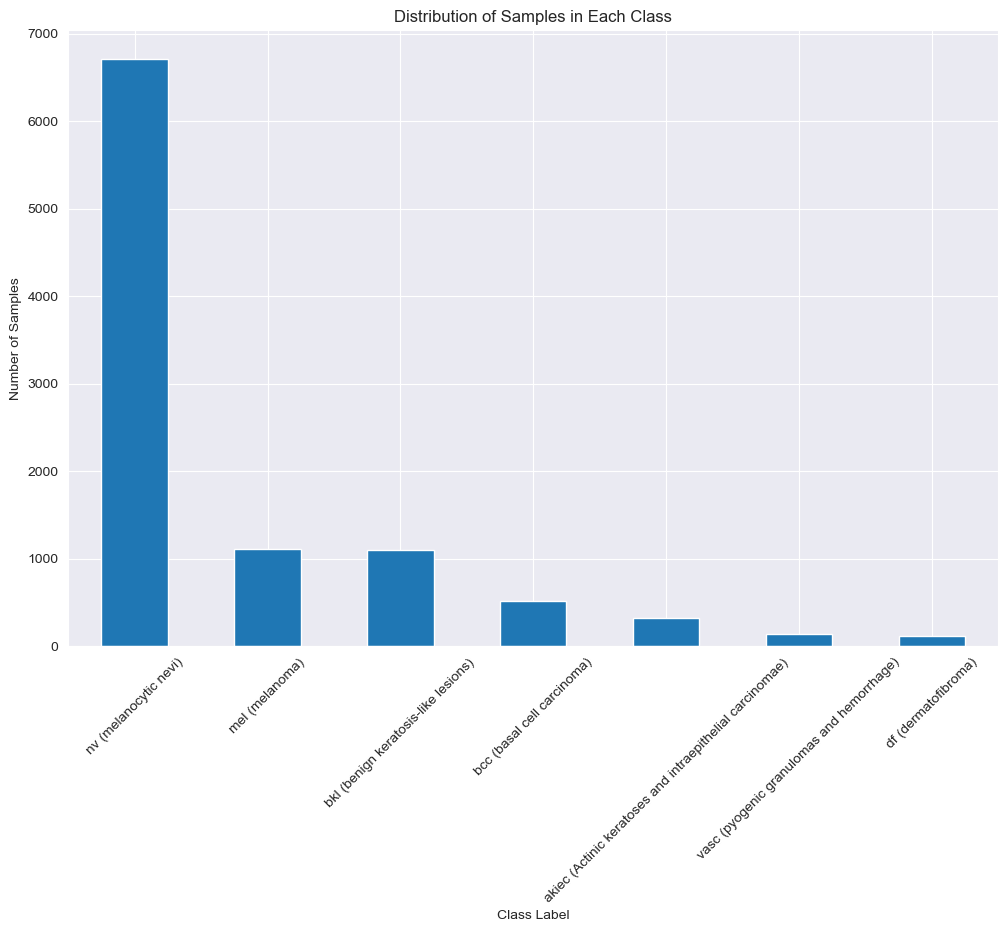

In [ ]:
# Create a new dictionary for combined labels
combined_labels = {key: f"{val[0]} ({val[1]})" for key, val in classes.items()}

# Calculate the value counts for each class
output_counts = output.value_counts()

# Show number of each class
print("Number of samples in each class:")
for class_label, count in output_counts.items():
    print(f"{combined_labels[class_label]}: {count} samples")
    # Plot
plt.figure(figsize=(12, 8))
output_counts.rename(index=combined_labels).plot(kind='bar')
plt.title('Distribution of Samples in Each Class')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.show()


Number of samples in each class after resampling:
Actinic keratoses and intraepithelial carcinomae: 6705 samples
dermatofibroma: 6705 samples
pyogenic granulomas and hemorrhage: 6705 samples
basal cell carcinoma: 6702 samples
benign keratosis-like lesions: 6597 samples
melanoma: 6595 samples
melanocytic nevi: 3464 samples


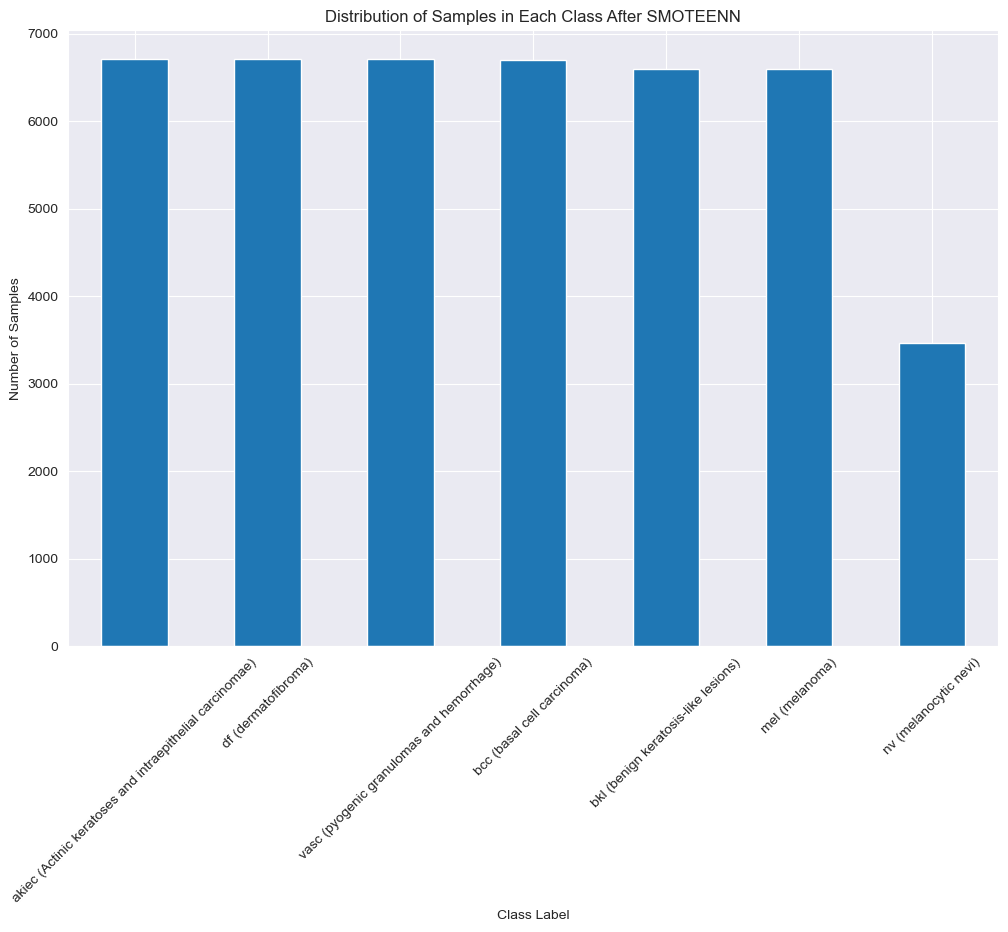

In [ ]:


import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from imblearn.combine import SMOTEENN  # استيراد SMOTEENN
import matplotlib.pyplot as plt

# Apply SMOTEENN to balance the data
smote_enn = SMOTEENN(random_state=42, sampling_strategy='auto')
data_resampled, output_resampled = smote_enn.fit_resample(data, output)

# Show number of samples in each class after resampling
output_counts = pd.Series(output_resampled).value_counts()

# Define classes
classes = {
    0: ('akiec', 'Actinic keratoses and intraepithelial carcinomae'),
      1: ('bcc', 'basal cell carcinoma'),
      2: ('bkl', 'benign keratosis-like lesions'),
     3: ('df', 'dermatofibroma'),
    4: ('nv', 'melanocytic nevi'),
    5: ('vasc', 'pyogenic granulomas and hemorrhage'),
    6: ('mel', 'melanoma')

}

# Print number of samples in each class after resampling
print("Number of samples in each class after resampling:")
for class_label, count in output_counts.items():
    print(f"{classes[class_label][1]}: {count} samples")

# Plot
plt.figure(figsize=(12, 8))
output_counts.rename(index={key: f"{val[0]} ({val[1]})" for key, val in classes.items()}).plot(kind='bar')
plt.title('Distribution of Samples in Each Class After SMOTEENN')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.show()


In [ ]:
# Splitting train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data_resampled, output_resampled, test_size=0.20, random_state=49)
# print(y_train)
# print(y_test)


print(y_train)
print(y_test)

23650    3
3497     0
36641    5
21780    3
2811     0
        ..
7924     1
19638    2
15861    2
29096    4
426      0
Name: label, Length: 34778, dtype: int64
34140    5
30596    5
41873    6
9586     1
8400     1
        ..
30400    5
10868    1
42923    6
43377    6
13365    1
Name: label, Length: 8695, dtype: int64


In [ ]:
# تقسيم البيانات إلى تدريب واختبار

# إعادة تشكيل البيانات إلى الشكل المطلوب (28x28x3)
# تحويل DataFrame إلى مصفوفة NumPy ثم إعادة تشكيلها
X_train = np.array(X_train).reshape(-1, 28, 28, 3)  # تأكد من الأبعاد صحيحة
X_test = np.array(X_test).reshape(-1, 28, 28, 3)    # افترض أن لديك بيانات اختبار بنفس الأبعاد

# تكبير البيانات باستخدام ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
   height_shift_range=0.2,
    shear_range=0.2,
  zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# تطبيق تكبير البيانات على مجموعة التدريب
datagen.fit(X_train)


In [ ]:
from tensorflow.keras.optimizers import Adadelta
from tensorflow.keras.utils import to_categorical  # Import this for one-hot encoding

# One-hot encode the labels
y_train_encoded = to_categorical(y_train, num_classes=7)  # Assuming you have 7 classes
y_test_encoded = to_categorical(y_test, num_classes=7)

from sklearn.model_selection import train_test_split

# افترض أن لديك data_resampled و output_resampled
print(f"Original data shape: {data_resampled.shape}")
print(f"Original output shape: {output_resampled.shape}")

# تقسيم البيانات إلى تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(data_resampled, output_resampled, test_size=0.20, random_state=49)

# تحقق من أبعاد البيانات بعد التقسيم
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# طباعة قيم y_train و y_test للتحقق من البيانات
print("y_train:", y_train)
print("y_test:", y_test)


Original data shape: (43473, 2352)
Original output shape: (43473,)
X_train shape: (34778, 2352)
X_test shape: (8695, 2352)
y_train shape: (34778,)
y_test shape: (8695,)
y_train: 23650    3
3497     0
36641    5
21780    3
2811     0
        ..
7924     1
19638    2
15861    2
29096    4
426      0
Name: label, Length: 34778, dtype: int64
y_test: 34140    5
30596    5
41873    6
9586     1
8400     1
        ..
30400    5
10868    1
42923    6
43377    6
13365    1
Name: label, Length: 8695, dtype: int64


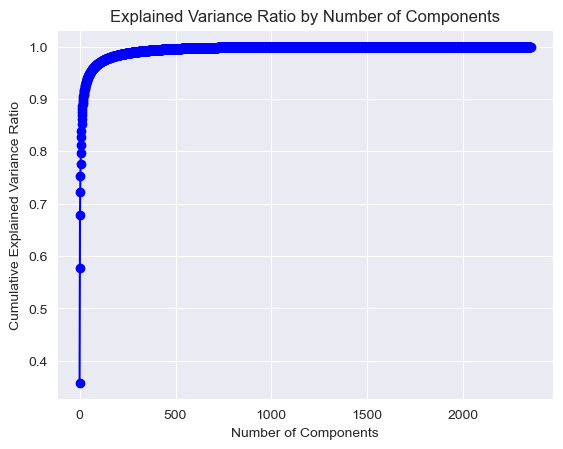

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# تحويل DataFrame إلى مصفوفة NumPy
X_train_flattened = X_train.to_numpy().reshape(X_train.shape[0], -1)

# apply the PCA
pca = PCA()
pca.fit(X_train_flattened)

#Calculate the proportion of variance explained
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

#plot the proportion of variance explainedplt.figure(figsize=(10, 6))
plt.plot(cumulative_variance, marker='o', linestyle='-', color='b')
plt.title('Explained Variance Ratio by Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)
plt.show()


In [ ]:
from sklearn.decomposition import PCA
import joblib

# Convert DataFrame to numpy array
X_train_flattened = X_train.values
X_test_flattened = X_test.values

# PCA
pca = PCA(n_components=400)
X_train_pca = pca.fit_transform(X_train_flattened)  # Apply PCA on the training data
X_test_pca = pca.transform(X_test_flattened)  # Apply PCA on the test data

# Save the PCA model
pca_save_path = r'C:\Users\TUF\Downloads\ham100000_dataset\pca_model.pkl'
joblib.dump(pca, pca_save_path)
print(f"PCA model saved to {pca_save_path}")


PCA model saved to C:\Users\TUF\Downloads\ham100000_dataset\pca_model.pkl


In [ ]:
# Define the model
model = Sequential()


# Create Model Structure
model.add(Dense(units=256, activation='relu', input_shape=(400,)))
model.add(BatchNormalization())
model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.20))  # Dropout rate of 20%
model.add(BatchNormalization())
model.add(Dense(units=64, activation='relu', kernel_regularizer=keras.regularizers.L1L2(l1=0.01, l2=0.01)))
model.add(BatchNormalization())
model.add(Dense(units=32, activation='relu', kernel_regularizer=keras.regularizers.L1L2(l1=0.01, l2=0.01)))
model.add(BatchNormalization())
model.add(Dense(units=7, activation='softmax', kernel_initializer='glorot_uniform', name='classifier'))  # Output layer for 7 classes

# Compile the CNN model with Adadelta optimizer
model.compile(optimizer=Adadelta(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the CNN model using the one-hot encoded labels
history = model.fit(X_train_pca, y_train_encoded, epochs=30, batch_size=120, validation_data=(X_test_pca, y_test_encoded))
# تدريب النموذج
# Save the model
model.save('C:\\Users\\TUF\\Downloads\\ham100000_dataset\\my_model-adadelta.h5')




Epoch 1/30


290/290 [==============================] - 13s 21ms/step - loss: 13.2824 - accuracy: 0.1687 - val_loss: 12.7986 - val_accuracy: 0.2240
Epoch 2/30
290/290 [==============================] - 5s 16ms/step - loss: 12.7111 - accuracy: 0.2486 - val_loss: 12.3310 - val_accuracy: 0.3300
Epoch 3/30
290/290 [==============================] - 5s 18ms/step - loss: 12.2854 - accuracy: 0.3113 - val_loss: 11.9434 - val_accuracy: 0.4031
Epoch 4/30
290/290 [==============================] - 5s 17ms/step - loss: 11.9240 - accuracy: 0.3546 - val_loss: 11.5922 - val_accuracy: 0.4598
Epoch 5/30
290/290 [==============================] - 5s 17ms/step - loss: 11.5774 - accuracy: 0.4045 - val_loss: 11.2593 - val_accuracy: 0.5004
Epoch 6/30
290/290 [==============================] - 5s 17ms/step - loss: 11.2456 - accuracy: 0.4386 - val_loss: 10.9379 - val_accuracy: 0.5346
Epoch 7/30
290/290 [==============================] - 5s 16ms/step - loss: 10.9258 - accuracy: 0.4710 - val_loss: 10.6209 - va

In [ ]:
# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test_pca, y_test_encoded, verbose=1)

# Print the test results
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")


272/272 [==============================] - 1s 2ms/step - loss: 5.3889 - accuracy: 0.8466
Test Loss: 5.38894510269165
Test Accuracy: 0.8465784788131714


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Step 1: Make predictions on the test data
y_pred_prob = model.predict(X_test_pca)  # Predict probabilities
y_pred = np.argmax(y_pred_prob, axis=1)  # Convert probabilities to class labels

# Step 2: Convert one-hot encoded y_test back to class labels
y_test_labels = np.argmax(y_test_encoded, axis=1)

# Step 3: Print the classification report
report = classification_report(y_test_labels, y_pred, target_names=['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5', 'Class 6'])
print(report)


272/272 [==============================] - 2s 6ms/step
              precision    recall  f1-score   support

     Class 0       0.86      0.93      0.89      1393
     Class 1       0.82      0.85      0.83      1252
     Class 2       0.76      0.55      0.64      1309
     Class 3       0.89      0.98      0.93      1333
     Class 4       0.88      0.83      0.86       709
     Class 5       0.85      1.00      0.92      1339
     Class 6       0.81      0.72      0.76      1360

    accuracy                           0.84      8695
   macro avg       0.84      0.84      0.83      8695
weighted avg       0.83      0.84      0.83      8695



In [ ]:
from sklearn.ensemble import RandomForestClassifier  # Changed import
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from keras.utils import to_categorical
import numpy as np

# Assuming y_train and y_test are defined elsewhere in the code
# One-hot encode the labels
y_train_encoded = to_categorical(y_train, num_classes=7)  # Assuming you have 7 classes
y_test_encoded = to_categorical(y_test, num_classes=7)

# Create a new model to extract CNN features
cnn_features_model = Model(inputs=model.input, outputs=model.layers[-2].output)

# Extract features using the CNN model
X_train_cnn_features = cnn_features_model.predict(X_train_pca)
X_test_cnn_features = cnn_features_model.predict(X_test_pca)

# Convert one-hot encoded labels to 1D format
y_train_1d = np.argmax(y_train_encoded, axis=1)  # Use y_train_encoded
y_test_1d = np.argmax(y_test_encoded, axis=1)    # Use y_test_encoded

# Concatenate CNN features with original features
X_train_concat = np.concatenate((X_train_pca, X_train_cnn_features), axis=1)
X_test_concat = np.concatenate((X_test_pca, X_test_cnn_features), axis=1)

# Standardize the features
scaler = StandardScaler()
X_train_concat = scaler.fit_transform(X_train_concat)
X_test_concat = scaler.transform(X_test_concat)

# Define the Random Forest classifier (Replaced SVM with Random Forest)
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the Random Forest classifier on the concatenated features
rf_classifier.fit(X_train_concat, y_train_1d)

# Predict the labels for the training and test sets
y_train_pred = rf_classifier.predict(X_train_concat)
y_test_pred = rf_classifier.predict(X_test_concat)
y_test_pred_proba = rf_classifier.predict_proba(X_test_concat)

# Print the classification report for the test set
print("Classification Report for Test Set:")
print(classification_report(y_test_1d, y_test_pred, target_names=[f'Class {i}' for i in range(7)]))


272/272 [==============================] - 1s 2ms/step
Classification Report for Test Set:
              precision    recall  f1-score   support

     Class 0       0.98      0.99      0.99      1393
     Class 1       0.97      0.99      0.98      1252
     Class 2       0.96      0.94      0.95      1309
     Class 3       1.00      1.00      1.00      1333
     Class 4       0.97      0.85      0.91       709
     Class 5       1.00      1.00      1.00      1339
     Class 6       0.92      0.97      0.95      1360

    accuracy                           0.97      8695
   macro avg       0.97      0.96      0.97      8695
weighted avg       0.97      0.97      0.97      8695



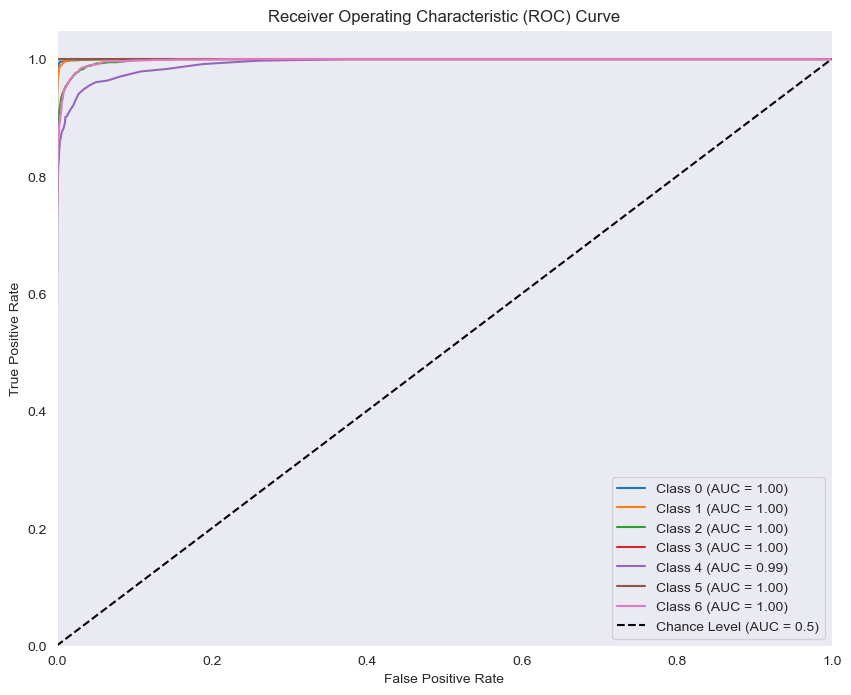

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Assuming you have y_test_encoded (one-hot encoded labels) and y_test_pred_proba (predicted probabilities)
n_classes = y_test_encoded.shape[1]  # Number of classes

# Create a plot
plt.figure(figsize=(10, 8))

# Loop over each class
for i in range(n_classes):
    # Compute ROC curve and ROC area for each class
    fpr, tpr, _ = roc_curve(y_test_encoded[:, i], y_test_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

# Plot the diagonal line (chance level)
plt.plot([0, 1], [0, 1], 'k--', label='Chance Level (AUC = 0.5)')

# Customize the plot
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc="lower right")
plt.grid()

# Show the plot
plt.show()



In [ ]:
# Define the class names (adjust these to match your dataset)
class_names = ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5', 'Class 6']

# Create a mapping from class index to class name
class_mapping = {i: class_names[i] for i in range(len(class_names))}

# Print the mapping
print("Class Code Mapping:")
for code, name in class_mapping.items():
    print(f"{code}: {name}")


#0: ('akiec', 'Actinic keratoses and intraepithelial carcinomae')
# 1: ('bcc', 'basal cell carcinoma'),
# 2: ('bkl', 'benign keratosis-like lesions'),
# 3: ('df', 'dermatofibroma')
# 4: ('nv', 'melanocytic nevi'),
# 5: ('vasc', 'pyogenic granulomas and hemorrhage')
# 6: ('mel', 'melanoma'),


Class Code Mapping:
0: Class 0
1: Class 1
2: Class 2
3: Class 3
4: Class 4
5: Class 5
6: Class 6


272/272 [==============================] - 1s 2ms/step


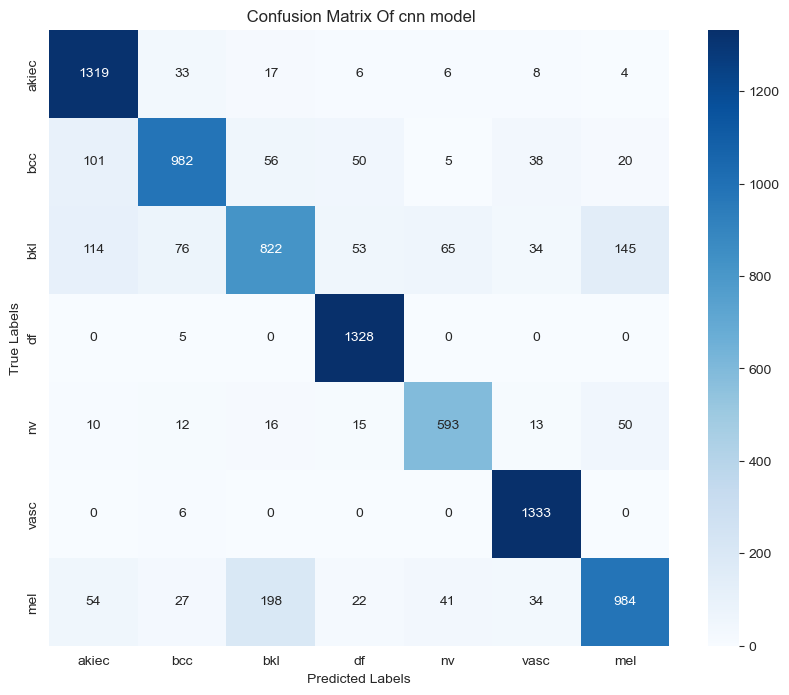

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

#1. Predicting values using the trained model
y_pred = model.predict(X_test_pca)  # Use PCA test data
y_pred_classes = np.argmax(y_pred, axis=1)  # Turning predictions into categories
#2. converting y_test_encoded to categories
y_test_classes = np.argmax(y_test_encoded, axis=1)

#3. Confusion Matrix Generation
cm = confusion_matrix(y_test_classes, y_pred_classes)

# أسماء الفئات
class_names = [
    'akiec',         # Actinic keratoses and intraepithelial carcinomae
    'bcc',           # Basal cell carcinoma
    'bkl',           # Benign keratosis-like lesions
    'df',            # Dermatofibroma
    'nv',            # Melanocytic nevi
    'vasc',          # Pyogenic granulomas and hemorrhage
    'mel'            # Melanoma
]

# 4. رسم مصفوفة الارتباك
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,  # أسماء الفئات
            yticklabels=class_names)  # أسماء الفئات
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title(' Confusion Matrix Of cnn model')
plt.show()


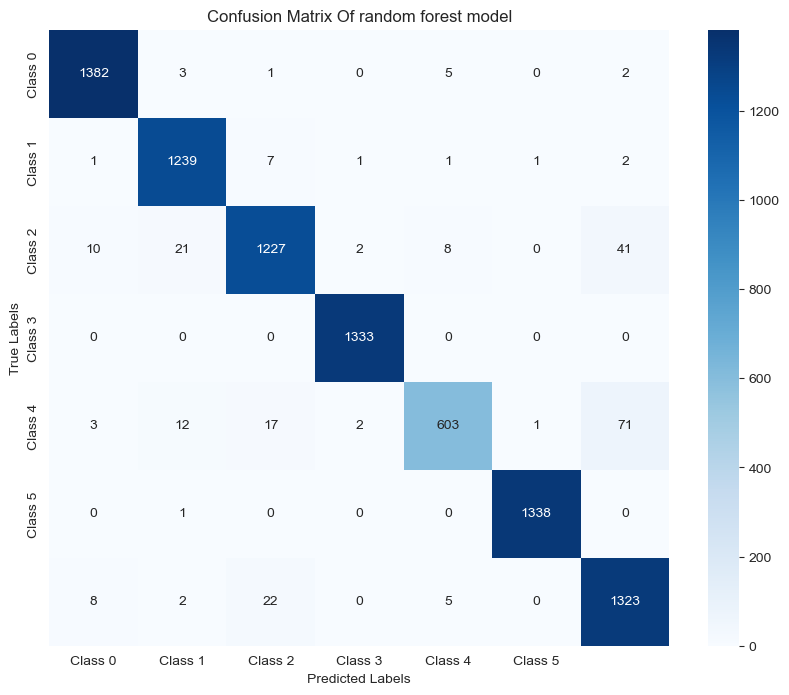

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming y_test_1d contains the true class labels and y_test_pred contains the predicted labels
# Generate the confusion matrix
cm = confusion_matrix(y_test_1d, y_test_pred)

# Create a heatmap to visualize the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Class {i}' for i in range(6)],
            yticklabels=[f'Class {i}' for i in range(6)])

# Add labels and title
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Of random forest model')
plt.show()


In [ ]:
# Evaluate the performance of the combined model
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(y_train_1d, y_train_pred)
test_accuracy = accuracy_score(y_test_1d, y_test_pred)
print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)
# Generate and print the classification report
report = classification_report(y_test_1d, y_test_pred)
print(report)


Train Accuracy: 1.0
Test Accuracy: 0.9712478435882691
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1393
           1       0.97      0.99      0.98      1252
           2       0.96      0.94      0.95      1309
           3       1.00      1.00      1.00      1333
           4       0.97      0.85      0.91       709
           5       1.00      1.00      1.00      1339
           6       0.92      0.97      0.95      1360

    accuracy                           0.97      8695
   macro avg       0.97      0.96      0.97      8695
weighted avg       0.97      0.97      0.97      8695



In [ ]:
from sklearn.metrics import accuracy_score, log_loss, classification_report

# Train the Random Forest classifier once on the concatenated features
rf_classifier = RandomForestClassifier(n_estimators=200, max_features='sqrt', max_depth=30, min_samples_split=2, min_samples_leaf=2, bootstrap=False, random_state=42)
rf_classifier.fit(X_train_concat, y_train_1d)

# Predict the labels for the training and test sets
y_train_pred = rf_classifier.predict(X_train_concat)
y_test_pred = rf_classifier.predict(X_test_concat)

# Predict probabilities for log loss calculation
y_train_pred_proba = rf_classifier.predict_proba(X_train_concat)
y_test_pred_proba = rf_classifier.predict_proba(X_test_concat)

# Evaluate the performance of the combined model
train_accuracy = accuracy_score(y_train_1d, y_train_pred)
test_accuracy = accuracy_score(y_test_1d, y_test_pred)

# Calculate log loss for training and testing
train_loss = log_loss(y_train_1d, y_train_pred_proba)
test_loss = log_loss(y_test_1d, y_test_pred_proba)

# Display results
print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)
print("Train Loss:", train_loss)
print("Test Loss:", test_loss)

# Generate and print the classification report
report = classification_report(y_test_1d, y_test_pred)
print(report)


Train Accuracy: 1.0
Test Accuracy: 0.9768832662449684
Train Loss: 0.0327415424660773
Test Loss: 0.2157938194606116
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1393
           1       0.98      0.99      0.99      1252
           2       0.97      0.95      0.96      1309
           3       1.00      1.00      1.00      1333
           4       0.97      0.86      0.92       709
           5       1.00      1.00      1.00      1339
           6       0.93      0.98      0.96      1360

    accuracy                           0.98      8695
   macro avg       0.98      0.97      0.97      8695
weighted avg       0.98      0.98      0.98      8695



In [ ]:

# Save the Trained Model
model_save_path = r'C:\Users\TUF\Downloads\ham100000_dataset\my_model_adadelta.h5'
model.save(model_save_path)
print(f"\nModel saved to {model_save_path}")




Model saved to C:\Users\TUF\Downloads\ham100000_dataset\my_model_adadelta.h5
